# EDA & Dataset Bias Analysis

Two goals:
1. Understand the data (size, distribution, text length)
2. Confirm dataset bias (subject-column leakage, Reuters byline)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../results', exist_ok=True)

## 1. Load & Merge Data

In [14]:
fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Fake: {len(fake):,} rows')
print(f'True: {len(true):,} rows')
print(f'Total: {len(df):,} rows')
df.head(3)

Fake: 23,481 rows
True: 21,417 rows
Total: 44,898 rows


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


数据集共 44,898 条，假新闻（23,481）略多于真新闻（21,417），两类数量基本均衡，不存在严重的类别不平衡问题。

The dataset is roughly balanced — no significant class imbalance to account for.

## 2. Class Distribution

label
Fake    23481
Real    21417
Name: count, dtype: int64


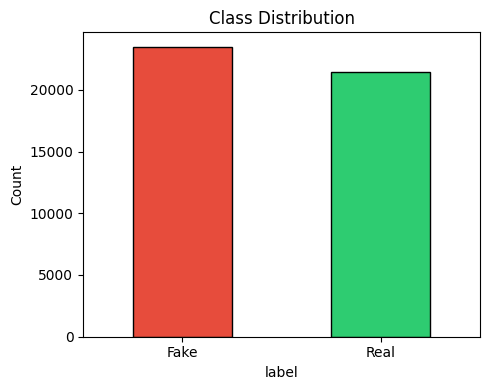

In [15]:
counts = df['label'].value_counts().rename({0: 'Fake', 1: 'Real'})
print(counts)

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(['Fake', 'Real'], rotation=0)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## 3. Dataset Bias Check

在正式训练模型之前，需要先检查数据集本身是否存在捷径特征（shortcut features）——即某些列或词语不代表新闻内容的真假，但却能让模型轻易达到高准确率。这类问题在 NLP 数据集中很常见，被称为 **label leakage（标签泄露）**。

Before training any model, we check whether the dataset contains shortcut features — columns or patterns that correlate perfectly with the label but have nothing to do with whether the content is actually true or false.

这里重点检查两个可疑的地方：`subject` 列和正文中的 `(Reuters)` 署名。

Two specific signals are investigated: the `subject` column and the Reuters byline in the article body.

**为什么是这两个？/** Why these two?

这个数据集的构造方式决定了问题所在：真新闻全部从 Reuters 官网爬取，假新闻全部从假新闻收集网站爬取。两个来源的分类标签和文章格式完全不同，`subject` 是来源网站自己打的标签，Reuters 署名是路透社固定的文章格式。这两个信号都和"内容是否真实"无关，只和"文章从哪里来"有关。

The dataset is constructed by scraping real news from Reuters and fake news from misinformation aggregator sites. Both the `subject` tags and the Reuters byline reflect **the source of the article, not the truthfulness of its content**.

In [16]:
print('=== Fake news subjects ===')
print(fake['subject'].value_counts())
print()
print('=== Real news subjects ===')
print(true['subject'].value_counts())

=== Fake news subjects ===
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

=== Real news subjects ===
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


两类新闻的 subject 标签完全没有重叠：真新闻只有 `politicsNews` 和 `worldnews`，假新闻用的是 `News`、`politics`、`left-news` 等完全不同的标签。光看这一列就能把两类分开，根本不需要读文章内容。

The subject tags are completely non-overlapping between fake and real news — a clear sign of label leakage.

In [17]:
from sklearn.metrics import accuracy_score

subject_label_map = df.groupby('subject')['label'].mean().round().astype(int)
df['subject_pred'] = df['subject'].map(subject_label_map)

acc = accuracy_score(df['label'], df['subject_pred'])
print(f'Accuracy using subject column only: {acc:.1%}')

Accuracy using subject column only: 100.0%


仅用 `subject` 列就达到了 **100% 准确率**，这说明这一列完全泄露了标签。换句话说，模型根本不需要读文章——只要看一眼 subject 是 `politicsNews` 还是 `News`，就能判断真假。

这也部分解释了原论文中 LSTM 为什么能达到 99% accuracy。原论文的输入包含了 `subject` 和 `date` 等列，LSTM 很可能直接利用了这个信号，而不是真正学会了识别假新闻的语言特征。这不代表 LSTM 不好，而是说这个数据集的设计给了模型"作弊"的机会。

因此，后续所有受控实验（baseline、DistilBERT）将**只使用 `title + text`**，排除 `subject` 和 `date`，以评估模型真正从内容中学到了什么。

`subject` alone achieves **100% accuracy**, meaning the label is entirely determined by this column — no article content needed. This likely contributed to the 99% accuracy reported in the original paper, where `subject` was included in the input. It is not a reflection of the model's language understanding, but a dataset artifact. All subsequent controlled experiments will use **`title + text` only**.

## 4. Reuters Byline — Leakage Check

In [18]:
true['has_reuters'] = true['text'].str.contains(r'\(Reuters\)', na=False)
fake['has_reuters'] = fake['text'].str.contains(r'\(Reuters\)', na=False)

print(f'Real news with Reuters byline: {true["has_reuters"].mean():.1%}')
print(f'Fake news with Reuters byline: {fake["has_reuters"].mean():.1%}')

Real news with Reuters byline: 99.2%
Fake news with Reuters byline: 0.0%


真新闻正文中 99.2% 包含 `(Reuters)` 字样，假新闻中为 0%。这是第二个泄露来源——模型只需认出这个署名就能判断真假，而不需要真正理解文章。这也部分解释了原论文 99% accuracy 的来源。

99.2% of real articles contain a Reuters byline; 0% of fake articles do. This is a second leakage source — a model can classify correctly simply by detecting the byline, without understanding the content at all.

## 5. Text Length Distribution

文章长度本身也可能是一个区分特征。如果真假新闻的长度差异明显，模型可能会利用这个信号而不是语言内容本身。

Article length can itself be a discriminating feature. If real and fake news differ significantly in length, models may exploit this pattern rather than learning from the actual language.

=== Text length (word count) by label ===
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      23481.0  423.0  408.0  0.0  240.0  363.0  506.0  8135.0
1      21417.0  386.0  274.0  0.0  148.0  359.0  525.0  5172.0


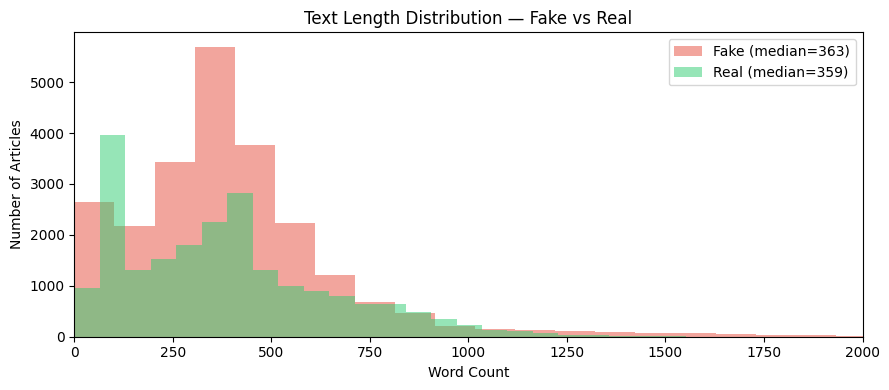

In [20]:
df['text_len'] = df['text'].str.split().str.len()

print('=== Text length (word count) by label ===')
print(df.groupby('label')['text_len'].describe().round(0))

fig, ax = plt.subplots(figsize=(9, 4))

for label, name, color in zip([0, 1], ['Fake', 'Real'], ['#e74c3c', '#2ecc71']):
    subset = df[df['label'] == label]['text_len']
    ax.hist(subset, bins=80, color=color, alpha=0.5, label=f'{name} (median={subset.median():.0f})')

ax.set_title('Text Length Distribution — Fake vs Real')
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Articles')
ax.set_xlim(0, 2000)
ax.legend()
plt.tight_layout()
plt.savefig('../results/text_length_distribution.png', dpi=150)
plt.show()

真假新闻的文章长度分布高度重叠，从叠加图中可以看到两条曲线几乎贴合在一起。假新闻中位数约 363 词，真新闻约 359 词，差异不足 1%。假新闻的分布更分散（标准差 408 vs 274），有更多极长或极短的文章，但这不构成可靠的区分信号。

The overlapping histogram shows that real and fake news have nearly identical length distributions — medians of 363 vs 359 words, less than 1% apart. Fake news is more spread out (std 408 vs 274), but this variance alone is not enough to reliably separate the two classes.

与 `subject` 列（100% 准确率）和 Reuters 署名（99.2% 覆盖）不同，**文章长度不是泄露来源**，模型无法靠它走捷径。

Unlike the `subject` column and the Reuters byline, **text length is not a leakage source** — models must engage with the actual content to distinguish real from fake news.